<a href="https://colab.research.google.com/github/amatullahaloula/Lab1A-Drone-Pathfinding/blob/main/Mohamet_Aloula_Lab_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 Part B: OOP Informed Search Algorithms for Drone Pathfinding

**Student:** Na'ima Mohamet Aloula

**Course:** Intro to A.I  

**Date:** June 2026

## 1. Setup and Imports

In [6]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 2. Foundations from Part A (with TODOs completed)

In [7]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        pass

In [8]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [9]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from root to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from root to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    return pd.DataFrame([result_to_row(r) for r in results])

In [10]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self):
        return self.start

    # TODO 1 COMPLETE: Check if we have reached the goal
    def is_goal(self, state):
        # Simply check if the current cell equals the goal cell
        return state == self.goal

    def in_bounds(self, state):
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state):
        row, col = state
        return self.grid[row][col] == 0

    # TODO 2 COMPLETE: Return all legal moves from this position
    def actions(self, state):
        row, col = state
        legal_actions = []  # Start with an empty list

        for action, (dr, dc) in MOVES.items():
            # Where would this move take us?
            neighbour = (row + dr, col + dc)
            # Only legal if inside the grid AND not an obstacle
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)

        return legal_actions

    # TODO 3 COMPLETE: Apply action to get next state
    def result(self, state, action):
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    # TODO 4 COMPLETE: Every move costs 1 on a plain grid
    def action_cost(self, state, action, next_state):
        return 1

In [11]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    # TODO 5 COMPLETE: Generate all child nodes from current node
    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        for action in problem.actions(s):
            next_state = problem.result(s, action)
            # New cost = cost so far + cost of this move
            cost = node.path_cost + problem.action_cost(s, action, next_state)
            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [12]:
def plot_path(
    grid, start=None, goal=None, path=None,
    terrain_costs=None, title="Grid Map"
):
    arr = np.array(grid)
    height, width = arr.shape
    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)
            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row), 1, 1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5, row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center", va="center", fontsize=8,
                )
    plt.show()

## 3. Weighted Terrain: WeightedGridProblem


In [13]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(self, grid, start, goal, terrain_costs):
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    # TODO 1 (WeightedGridProblem) COMPLETE
    def action_cost(self, state, action, next_state):
        # The cost = terrain cost of the cell we are FLYING INTO
        row, col = next_state
        return self.terrain_costs[row][col]

In [14]:
# 3.1 Self-Check for WeightedGridProblem
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]
wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]
wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True
print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


## 4. Heuristic Functions



In [15]:
# TODO 2 COMPLETE: Manhattan distance
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # Count steps needed going only up/down/left/right
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


# TODO 3 COMPLETE: Euclidean (straight-line) distance
def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # Straight-line distance using Pythagoras theorem
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 — makes A* behave like Uniform-Cost Search."""
    return 0.0

In [16]:
# 4.2 Self-Check for Heuristics
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


## 5. The Priority-Queue Frontier



In [17]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

## 6. The BestFirstSearch Framework



In [18]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define f(n) via evaluation()."""

    algorithm_name = "BestFirst"

    def __init__(self, heuristic=zero_heuristic):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate h(n) from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n) — subclasses override this one method to change the algorithm."""
        raise NotImplementedError("Subclasses must define evaluation()")

    # TODO 4 COMPLETE: The main search loop
    def search(self, problem: Problem) -> SearchResult:

        # Step 1: Create the starting node
        initial = Node(state=problem.initial_state())

        # Step 2: Priority queue — always pops the node with lowest f(n)
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial, problem), initial)

        # Step 3: reached is a DICTIONARY (state -> best Node found so far)
        # We need a dict because we might find a cheaper path to a state later
        reached = {initial.state: initial}

        # Step 4: Counters for reporting
        nodes_expanded = 0
        max_frontier_size = 1

        # Step 5: Main loop — keep going until frontier is empty
        while frontier:

            # Always pop the node with the LOWEST f(n)
            node = frontier.pop()

            # LATE GOAL TEST: only accept goal when we pop it
            # Why? A cheaper path to goal might still be in the frontier!
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached)
                )

            nodes_expanded += 1

            # Expand: look at all neighbouring cells
            for child in self.expand(problem, node):
                s = child.state

                # Add child to frontier if:
                # - we have never visited this state before, OR
                # - we found a CHEAPER way to reach it
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            # Track the largest the frontier ever grew
            max_frontier_size = max(max_frontier_size, len(frontier))

        # If we emptied the frontier without finding the goal → failure
        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

## 7. Greedy Best-First Search

Greedy Best-First Search uses f(n) = h(n), only looking at estimated distance to goal.

In [19]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    # TODO 5 COMPLETE: f(n) = h(n) — only the heuristic
    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node, problem)

## 8. A* Search

A* uses f(n) = g(n) + h(n), balancing cost paid with estimated remaining cost.



In [20]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    # TODO 6 COMPLETE: f(n) = g(n) + h(n)
    def evaluation(self, node: Node, problem: Problem) -> float:
        # g(n) = node.path_cost (cost paid so far)
        # h(n) = estimated remaining cost
        return node.path_cost + self.h(node, problem)

## 9. Uniform-Cost Search
**f(n) = g(n)**  
 A* with h(n) = 0. Blind but optimal. Perfect baseline to measure how much the heuristic helps.



In [21]:
class UniformCostSearch(BestFirstSearch):
    """UCS = A* with h(n) = 0. Provided."""
    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

## 10. Weighted A* Search
f(n) = g(n) + W·h(n), with W > 1

In [22]:
class WeightedAStarSearch(BestFirstSearch):

    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    # TODO 7 COMPLETE: f(n) = g(n) + W * h(n)
    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.weight * self.h(node, problem)

In [23]:
# 10.1 Self-Check for All Algorithms
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed"
    assert res.solution_cost == 4, f"{res.algorithm} cost={res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# Failure case: goal is walled off
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0), goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


## 11. Run the Algorithms on the Part A Sample Map



In [24]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


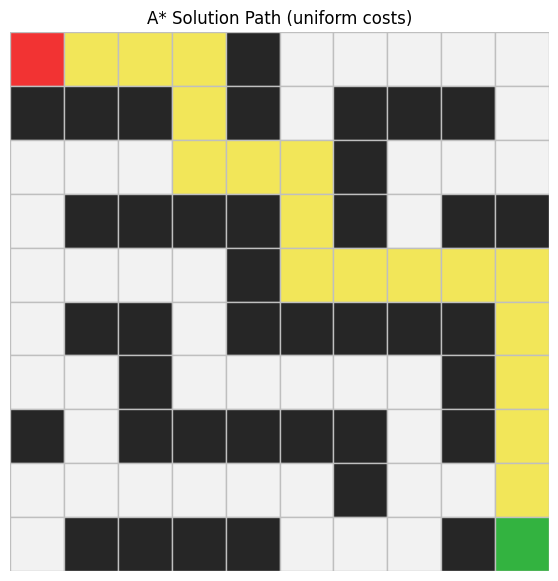

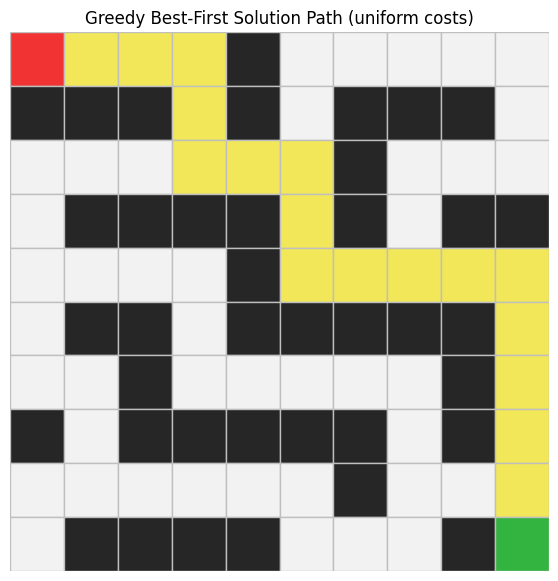

In [25]:
plot_path(
    sample_grid, start, goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid, start, goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

## 12. The Turbulence Map: Where Greedy Goes Wrong



In [26]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


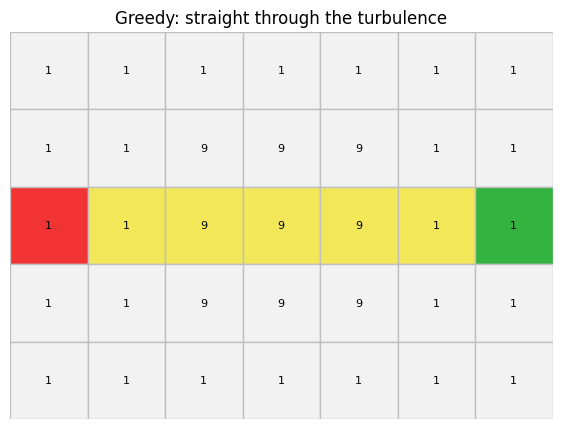

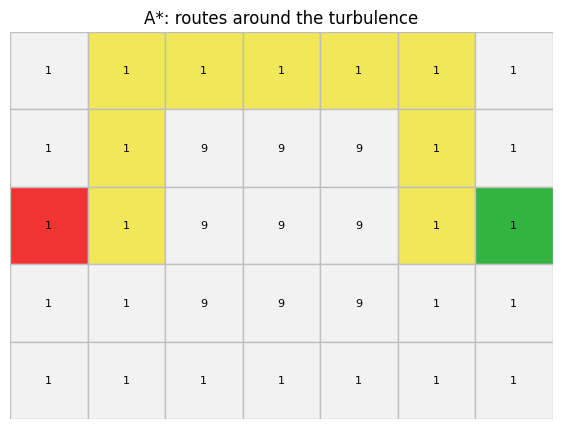

In [27]:
plot_path(
    turbulence_grid, t_start, t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid, t_start, t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

## 13. Experiment: Breaking Admissibility



In [28]:
# TODO 8 COMPLETE: Create an overestimating (inadmissible) heuristic
def inflated_heuristic(factor: float):
    # This is a CLOSURE — a function that returns another function
    # The inner function multiplies Manhattan distance by factor
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h  # Return the function itself, not a value

In [29]:
mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


In [30]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:

        initial_state = problem.initial_state()
        # Start the f-cost limit at the heuristic value of the initial state
        limit = self.heuristic(initial_state, problem.goal)

        nodes_expanded = 0
        max_depth_seen = 0
        iteration_log = []

        def f_limited_search(node, limit, path_states):
            nonlocal nodes_expanded, max_depth_seen

            f = node.path_cost + self.heuristic(node.state, problem.goal)
            max_depth_seen = max(max_depth_seen, node.depth)

            # If this node's f exceeds the limit, report how much it exceeded by
            if f > limit:
                return None, f

            # Late goal test
            if problem.is_goal(node.state):
                return node, f

            nodes_expanded += 1
            next_limit = math.inf

            for child in self.expand(problem, node):
                # Skip states already on the current path (cycle check)
                if child.state in path_states:
                    continue

                path_states.add(child.state)
                result, new_f = f_limited_search(child, limit, path_states)
                path_states.discard(child.state)

                if result is not None:
                    return result, new_f

                next_limit = min(next_limit, new_f)

            return None, next_limit

        for iteration in range(max_iterations):
            initial_node = Node(state=initial_state)
            path_states = {initial_state}

            result, next_limit = f_limited_search(initial_node, limit, path_states)
            iteration_log.append({"iteration": iteration, "limit": limit, "next_limit": next_limit})

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_depth_seen,
                    reached_count=0,
                    iterations=iteration_log
                )

            if next_limit == math.inf:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_depth_seen,
                    reached_count=0,
                    iterations=iteration_log
                )

            limit = next_limit

        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_depth_seen,
            reached_count=0,
            iterations=iteration_log
        )

In [31]:
# Compare IDA* with A* on the sample map
ida = IDAStarSearch(manhattan_distance)
show_results([
    astar.search(uniform_problem),
    ida.search(uniform_problem)
])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18,18,5,23
1,IDA*,success,18,18,18,18,0


## 15. Custom Maps

### Custom Map 1: The U-Shaped Trap (Heuristic Trap)

A U-shaped wall opening **away** from the goal forces Greedy to explore deep into a dead-end pocket before backing out. A\* handles this more gracefully because g(n) tells it the pocket is getting expensive.

In [32]:
# TODO 10 COMPLETE: Custom Map 1 — U-shaped heuristic trap
#
# Layout (S=start, G=goal, #=wall, .=free):
#  S . . . . . . . . .
#  . # # # # # # # . .
#  . # . . . . . # . .
#  . # . . . . . # . .
#  . # . . . . . # . .
#  . # # # # # # # . .
#  . . . . . . . . . .
#  . . . . . . . . . .
#  . . . . . . . . . .
#  . . . . . . . . . G
#
# The goal is bottom-right. The U-trap is in rows 1-5 cols 1-7.
# Greedy is lured into the open mouth of the U (rows 1-5 col 8)
# thinking it's heading toward the goal.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

# Uniform terrain costs (all 1) — obstacles vs free cells is what matters here
custom_costs_1 = [[1] * 10 for _ in range(10)]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,64,7,65
1,A*,success,18,18,64,7,65
2,Weighted A* (W=2),success,18,18,18,12,30
3,Greedy,success,18,18,18,12,30


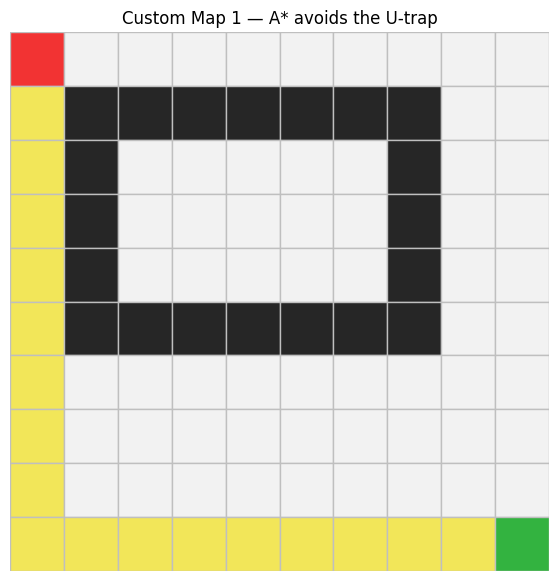

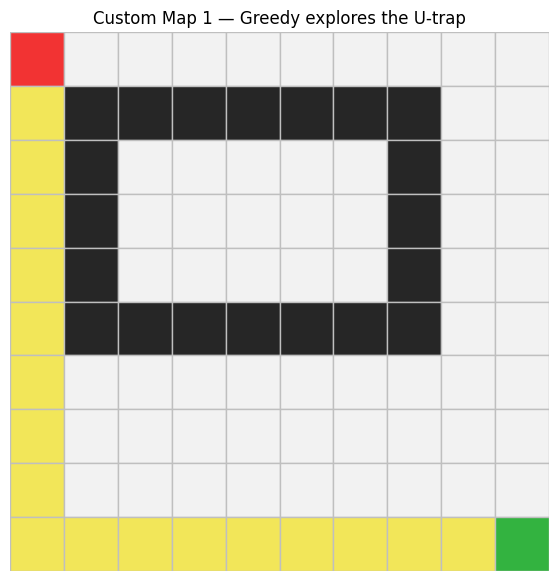

In [33]:
plot_path(
    custom_grid_1, custom_start_1, custom_goal_1,
    path=custom_results_1[1].path,
    title="Custom Map 1 — A* avoids the U-trap"
)

plot_path(
    custom_grid_1, custom_start_1, custom_goal_1,
    path=custom_results_1[3].path,
    title="Custom Map 1 — Greedy explores the U-trap"
)

### Interpretation — Custom Map 1

The U-shaped wall tricks Greedy Search because the cells inside the U look closer to the goal. As a result, it spends a lot of time exploring the dead-end area before finding the correct path. A* performs better because it considers both the distance to the goal and the cost of the path taken so far. UCS and A* both find the optimal path, while Greedy often wastes more steps exploring unnecessary nodes. This example shows that expanding fewer nodes does not always mean a search is more efficient.


### Custom Map 2: Cheap Long Way vs Expensive Short Way

A 15×15 weighted map where the direct path crosses expensive terrain (cost 8), but a longer detour costs only 1 per cell. This shows that the **shortest path ≠ cheapest path** and forces A\* and UCS to take the detour.

In [34]:
# TODO 11 COMPLETE: Custom Map 2 — cheap long way vs expensive short way
#
# A 15x15 open grid with no obstacles.
# Columns 6-8 have very high terrain cost (cost=8) — like flying over a restricted zone.
# The direct path (straight across) is short in steps but expensive.
# The detour (go around the top or bottom) is longer but much cheaper.

rows_2, cols_2 = 15, 15

custom_grid_2 = [[0] * cols_2 for _ in range(rows_2)]

# Terrain: default cost 1, expensive band in columns 6-8
custom_costs_2 = []
for r in range(rows_2):
    row_costs = []
    for c in range(cols_2):
        if 6 <= c <= 8 and 3 <= r <= 11:  # The expensive restricted zone
            row_costs.append(8)
        else:
            row_costs.append(1)
    custom_costs_2.append(row_costs)

custom_start_2 = (7, 0)   # Middle-left
custom_goal_2 = (7, 14)   # Middle-right

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,24,24,219,33,225
1,A*,success,24,24,140,59,191
2,Weighted A* (W=2),success,24,24,74,45,117
3,Greedy,success,14,35,14,29,43


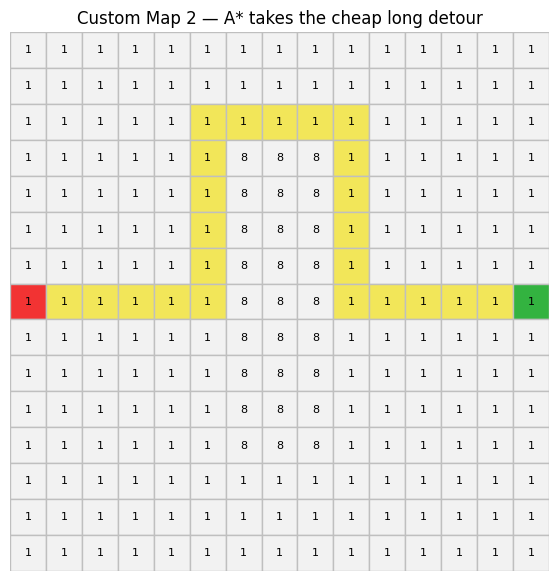

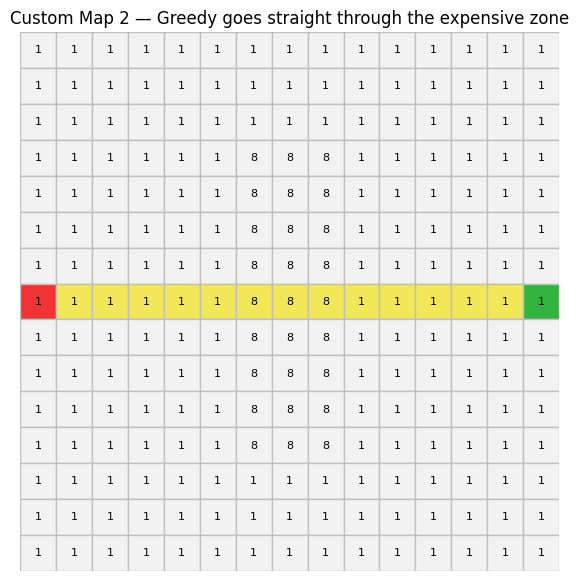

In [35]:
plot_path(
    custom_grid_2, custom_start_2, custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="Custom Map 2 — A* takes the cheap long detour"
)

plot_path(
    custom_grid_2, custom_start_2, custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Custom Map 2 — Greedy goes straight through the expensive zone"
)

### Interpretation — Custom Map 2

This 15×15 map clearly shows the difference between path length and path cost. Greedy Search chooses the direct path through the cost-8 restricted area because it looks like the fastest way to reach the goal. However, A* and UCS avoid this area since they consider the total cost of the path, not just the distance. They take a longer route through the cheaper corridors, which results in a lower overall cost. Weighted A* (W=2) may still choose the direct path if the heuristic has a stronger influence. This example shows that the shortest path is not always the cheapest path, and informed search algorithms focus on minimizing cost rather than the number of steps.



## 16.1 Heuristic Functions

**1. What does h(n) estimate, and where does its knowledge come from?**

h(n) estimates the remaining cost from the current cell to the goal. It uses the position of the current cell and the goal to calculate the distance between them.

**2. Which restrictions does the Manhattan relaxation remove?**

Manhattan distance ignores obstacles and terrain costs. It assumes the drone can move freely and every step costs 1.

**3. Which heuristic dominates the other?**

Manhattan distance dominates Euclidean distance because it is usually larger but still does not overestimate the real cost. This helps A* make better decisions.

**4. Why do terrain costs ≥ 1 keep Manhattan admissible?**

Manhattan distance counts the minimum number of moves. If every move costs at least 1, the real path cost will always be equal to or higher than the Manhattan distance.

## 16.2 Greedy Best-First Search

**1. Which quantity does Greedy ignore, and how did the turbulence map punish it?**

Greedy ignores g(n), which is the cost already spent. It chose the direct route through expensive cells and ended up with a high-cost path.

**2. Why is expanding fewer nodes not enough to call Greedy the better algorithm?**

Expanding fewer nodes only means the search is faster. It does not mean the path found is good or cheap.

**3. When would Greedy be acceptable for a drone mission?**

Greedy can be useful when reaching the goal quickly is more important than saving battery or finding the best path.

## 16.3 A* Search

**1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.**

A* adds the cost already used and the estimated cost to the goal, then chooses the path with the lowest total value.

**2. Why must A * apply the goal test at pop time, not generation time?**

When the goal is first found, there may still be a cheaper path available. Waiting until the goal is removed from the frontier guarantees the best solution.

**3. Why does reached need to be a dictionary instead of a set?**

A dictionary stores the cheapest path to each state. This allows A* to update a state if a better path is found later.

**4. What does the UCS vs A* node count gap tell us?**

It shows how many nodes the heuristic helped avoid exploring. A bigger gap means the heuristic is more useful.

## 16.4 Admissibility and Consistency

**1. State the definitions.**

* Admissible: the heuristic never overestimates the real cost.
* Consistent: the heuristic follows the triangle inequality and stays reliable between connected states.

**2. What did the inadmissible-heuristic experiment show?**

The experiment showed that an inflated heuristic can produce a more expensive path, so optimality is not guaranteed.

**3. Is Manhattan distance consistent on a unit-cost grid?**

Yes. Each move changes the Manhattan distance by at most 1, and every move costs 1, so it is consistent.

## 16.5 Weighted A* and Trade-offs

**1. How does W interpolate between UCS, A*, and Greedy?**

When W=0, it behaves like UCS. When W=1, it is normal A*. As W gets larger, it becomes more like Greedy Search.

**2. What suboptimality bound does Weighted A* guarantee?**

The solution cost will be at most W times the optimal cost.

**3. With 90 seconds of battery margin and a slow computer, which algorithm?**

I would choose Weighted A* with W=2 because it is faster than A* and still gives a reasonably good path.

## 16.6 Memory and Real-World Drone Context

**1. What makes A* memory-hungry, and how does IDA* help?**

A* stores many nodes in memory. IDA* uses much less memory because it only stores the current path.

**2. What would you add to terrain costs in a real drone?**

I would include weather conditions, no-fly zones, battery level, and communication signal strength.

**3. What breaks if the target is moving?**

The heuristic may become inaccurate because the goal position keeps changing, making the search less effective.

**4. Which single algorithm would you ship on the drone?**

I would choose A* with Manhattan distance because it finds the best path and works efficiently in most situations.
